# Long-Form Sound Generation (5-8 seconds)

Generate longer audio segments by training the pipeline on short clips and
stitching them via **overlap-and-add**. Post-processing knobs let you shape
the generated audio with **pitch envelopes, amplitude envelopes (ADSR),
and timbral filtering**.

### Pipeline
1. Train on 1-second clips (fast on CPU)
2. Generate multiple short latents
3. Crossfade / overlap-and-add into a continuous 5-8s segment
4. Apply post-processing: pitch shift envelope, ADSR, lowpass/highpass

### Sound shaping knobs
- `PITCH_START` / `PITCH_END` — pitch envelope (semitone shift from base)
- `ADSR_ATTACK` / `ADSR_DECAY` / `ADSR_SUSTAIN` / `ADSR_RELEASE` — amplitude envelope
- `LP_CUTOFF` / `HP_CUTOFF` — timbral filtering (Hz)
- `SEGMENT_SECONDS` — total output length (5-8s)
- `OVERLAP_FRAC` — crossfade overlap between segments (0.25-0.75)
- `SEED`, `STEPS`, `TEMPERATURE`, `USE_C_SPEC` — generation knobs

In [1]:
# --- Generation knobs ---
SEED = 42
STEPS = 50
TEMPERATURE = 1.0
USE_C_SPEC = True

# --- Long-form knobs ---
SEGMENT_SECONDS = 6       # total output length (5-8)
OVERLAP_FRAC = 0.5        # crossfade overlap fraction (0.25-0.75)

# --- Pitch envelope knobs (semitones, applied as time-stretch ratio) ---
PITCH_START = 0.0         # starting pitch shift (semitones)
PITCH_END = 7.0           # ending pitch shift (semitones, e.g. +7 = perfect fifth up)
PITCH_CURVE = 'linear'    # 'linear' or 'exponential'

# --- Amplitude envelope (ADSR) knobs ---
ADSR_ATTACK = 0.05        # attack time in seconds
ADSR_DECAY = 0.1          # decay time in seconds
ADSR_SUSTAIN = 0.7        # sustain level (0-1)
ADSR_RELEASE = 0.3        # release time in seconds

# --- Timbral filtering knobs ---
LP_CUTOFF = 8000          # lowpass cutoff in Hz (0 = bypass)
HP_CUTOFF = 80            # highpass cutoff in Hz (0 = bypass)

# --- Training knobs ---
DECODER_EPOCHS = 20
DIFFUSION_EPOCHS = 20
CLIP_SECONDS = 1.0        # training clip length
NUM_SAMPLES = 64
SAMPLE_RATE = 24000

CLIP_LENGTH = int(CLIP_SECONDS * SAMPLE_RATE)
TOTAL_LENGTH = int(SEGMENT_SECONDS * SAMPLE_RATE)
print(f'Target: {SEGMENT_SECONDS}s ({TOTAL_LENGTH} samples @ {SAMPLE_RATE}Hz)')
print(f'Training clips: {CLIP_SECONDS}s ({CLIP_LENGTH} samples)')
print(f'Pitch: {PITCH_START} -> {PITCH_END} semitones ({PITCH_CURVE})')
print(f'ADSR: A={ADSR_ATTACK} D={ADSR_DECAY} S={ADSR_SUSTAIN} R={ADSR_RELEASE}')
print(f'Filter: LP={LP_CUTOFF}Hz HP={HP_CUTOFF}Hz')

Target: 6s (144000 samples @ 24000Hz)
Training clips: 1.0s (24000 samples)
Pitch: 0.0 -> 7.0 semitones (linear)
ADSR: A=0.05 D=0.1 S=0.7 R=0.3
Filter: LP=8000Hz HP=80Hz


In [2]:
import math
import torch
import torch.nn as nn
import torchaudio
from IPython.display import Audio, display
import matplotlib.pyplot as plt

from ald_sc.build_prior import build_arrow_prior
from ald_sc.audio_codec import BaselineAudioDecoder, AudioVAE
from ald_sc.graph_decoder import GraphDecoder
from ald_sc.dit import MinimalDiT
from ald_sc.data import ToyAudioDataset, build_audio_dataloader
from ald_sc.losses import ALDSCLoss
from ald_sc.schedule import CosineSchedule
from ald_sc.sampling import sample_ddim
from ald_sc.trainer import train_audio_decoder, train_audio_diffusion

device = torch.device('cpu')
torch.manual_seed(SEED)
print('Ready. Device:', device)

Ready. Device: cpu


## Step 1: Build prior + train decoder + train DiT (on 1s clips)

Same pipeline as notebook 01, but encapsulated for reuse.

In [3]:
STRIDE = 320  # EnCodec 24kHz stride

class StubEncoder(nn.Module):
    def __init__(self, latent_dim=128, stride=320):
        super().__init__()
        self.proj = nn.Conv1d(1, latent_dim, stride, stride=stride)
    def encode(self, x, prior):
        z = self.proj(x).float()
        a = z.mean(dim=2)
        c_spec = prior.chart_energy_descriptor(a)
        return z, a, c_spec
    def extract_features(self, x):
        return self.proj(x).float()

encoder = StubEncoder()
latent_length = CLIP_LENGTH // STRIDE

# Build prior
dataset = ToyAudioDataset(num_samples=NUM_SAMPLES, audio_length=CLIP_LENGTH)
loader = build_audio_dataloader(dataset, batch_size=8, shuffle=False)
features = []
for batch in loader:
    features.append(encoder.extract_features(batch).mean(dim=2))
embeddings = torch.cat(features, dim=0)
prior = build_arrow_prior(embeddings, q=8, k=4)
print(f'Prior: L_F={prior.L_F.shape}, q={prior.q}')

# Train graph decoder
graph_decoder = GraphDecoder(
    latent_channels=128, out_channels=1, feature_dim=128,
    base_channels=32, prior=prior, upsample_strides=(2, 4, 5, 8),
)
baseline_decoder = BaselineAudioDecoder(
    latent_channels=128, out_channels=1, base_channels=32,
    upsample_strides=(2, 4, 5, 8),
)
loss_fn = ALDSCLoss(prior=prior, lambda_rec=1.0, lambda_stft=0.0,
                    lambda_chart=0.5, lambda_smooth=0.1)
train_loader = build_audio_dataloader(dataset, batch_size=4, shuffle=True)

graph_vae = AudioVAE(encoder=encoder, decoder=graph_decoder)
print('Training graph decoder...')
gl = list(train_audio_decoder(train_loader, graph_vae, prior, loss_fn,
                              epochs=DECODER_EPOCHS, lr=1e-3, device=device))
print(f'  {gl[0]["loss"]:.4f} -> {gl[-1]["loss"]:.4f}')

baseline_vae = AudioVAE(encoder=encoder, decoder=baseline_decoder)
print('Training baseline decoder...')
bl = list(train_audio_decoder(train_loader, baseline_vae, prior, loss_fn,
                              epochs=DECODER_EPOCHS, lr=1e-3, device=device))
print(f'  {bl[0]["loss"]:.4f} -> {bl[-1]["loss"]:.4f}')

# Train DiT
dit = MinimalDiT(
    latent_channels=128, latent_length=latent_length,
    patch_size=8, dim=64, depth=2, num_heads=4, spec_dim=24,
)
sched = CosineSchedule(num_steps=1000)
for p in graph_vae.parameters():
    p.requires_grad_(False)
print('Training DiT...')
dl = list(train_audio_diffusion(train_loader, graph_vae, dit, prior, sched,
                                epochs=DIFFUSION_EPOCHS, lr=1e-3, device=device))
print(f'  {dl[0]["loss"]:.4f} -> {dl[-1]["loss"]:.4f}')

Prior: L_F=torch.Size([128, 128]), q=8
Training graph decoder...
  0.5321 -> 0.1147
Training baseline decoder...
  0.5375 -> 0.1035
Training DiT...
  0.6571 -> 0.6042


## Step 2: Generate multiple segments and stitch with overlap-and-add

Each segment is a 1s clip generated from independent noise. We crossfade
them with `OVERLAP_FRAC` to create a continuous long-form output.

In [4]:
def generate_segment(seed_val, steps, temperature, use_cspec):
    """Generate a single 1-second audio segment."""
    z = sample_ddim(dit, sched, batch_size=1, steps=steps, seed=seed_val, device=device)
    z = z * temperature
    a = z.mean(dim=2)
    c_spec = prior.chart_energy_descriptor(a)
    with torch.no_grad():
        if use_cspec:
            audio = graph_decoder(z, c_spec)
        else:
            audio = graph_decoder(z, torch.zeros_like(c_spec))
    return audio.squeeze(0).squeeze(0)  # (T,)

def overlap_add(segments, overlap_frac, sample_rate):
    """Stitch segments with crossfade overlap-and-add."""
    seg_len = segments[0].shape[-1]
    overlap = int(seg_len * overlap_frac)
    hop = seg_len - overlap
    total_len = hop * (len(segments) - 1) + seg_len
    output = torch.zeros(total_len)
    window = torch.linspace(0, 1, overlap)  # linear crossfade
    for i, seg in enumerate(segments):
        start = i * hop
        output[start:start + seg_len] += seg
        if i > 0:
            # Apply crossfade in overlap region
            fade_in = window
            fade_out = 1 - window
            prev_overlap_start = start - overlap
            output[prev_overlap_start:prev_overlap_start + overlap] *= fade_out
            output[start:start + overlap] *= fade_in
    return output

# Determine how many segments we need
clip_samples = CLIP_LENGTH
hop_samples = int(clip_samples * (1 - OVERLAP_FRAC))
num_segments = max(2, math.ceil((TOTAL_LENGTH - clip_samples) / hop_samples) + 1)
print(f'Generating {num_segments} segments (hop={hop_samples} samples, overlap={int(clip_samples * OVERLAP_FRAC)} samples)')

# Generate segments with different seeds for variety
segments = []
for i in range(num_segments):
    seg_seed = SEED + i * 1000
    seg = generate_segment(seg_seed, STEPS, TEMPERATURE, USE_C_SPEC)
    segments.append(seg)
    print(f'  Segment {i+1}/{num_segments} (seed={seg_seed}): {seg.shape[-1]} samples')

# Stitch
raw_audio = overlap_add(segments, OVERLAP_FRAC, SAMPLE_RATE)
# Crop to target length
if raw_audio.shape[-1] > TOTAL_LENGTH:
    raw_audio = raw_audio[:TOTAL_LENGTH]
elif raw_audio.shape[-1] < TOTAL_LENGTH:
    raw_audio = torch.nn.functional.pad(raw_audio, (0, TOTAL_LENGTH - raw_audio.shape[-1]))

# Normalize
peak = raw_audio.abs().max()
if peak > 0:
    raw_audio = raw_audio / peak

print(f'Stitched audio: {raw_audio.shape[-1]} samples ({raw_audio.shape[-1]/SAMPLE_RATE:.2f}s)')

Generating 11 segments (hop=12000 samples, overlap=12000 samples)
  Segment 1/11 (seed=42): 24000 samples
  Segment 2/11 (seed=1042): 24000 samples
  Segment 3/11 (seed=2042): 24000 samples
  Segment 4/11 (seed=3042): 24000 samples
  Segment 5/11 (seed=4042): 24000 samples
  Segment 6/11 (seed=5042): 24000 samples
  Segment 7/11 (seed=6042): 24000 samples
  Segment 8/11 (seed=7042): 24000 samples
  Segment 9/11 (seed=8042): 24000 samples
  Segment 10/11 (seed=9042): 24000 samples
  Segment 11/11 (seed=10042): 24000 samples
Stitched audio: 144000 samples (6.00s)


## Step 3: Apply pitch envelope

Apply a time-varying pitch shift from `PITCH_START` to `PITCH_END`
semitones. We implement this via **variable-speed resampling**: divide
the audio into windows, compute a per-window pitch ratio, and resample
each window accordingly.

In [5]:
def apply_pitch_envelope(audio, pitch_start, pitch_end, curve='linear', sr=24000, window_ms=50):
    """Apply a time-varying pitch shift via variable-speed resampling.
    
    Divides audio into windows, linearly or exponentially interpolates
    the pitch ratio from pitch_start to pitch_end semitones, and
    resamples each window.
    """
    if pitch_start == 0 and pitch_end == 0:
        return audio
    
    window_samples = int(sr * window_ms / 1000)
    num_windows = max(1, len(audio) // window_samples)
    
    if curve == 'exponential':
        # Exponential pitch curve (perceptually linear)
        pitches = torch.linspace(0, 1, num_windows)
        pitches = pitch_start * (1 - pitches) + pitch_end * pitches
    else:
        pitches = torch.linspace(pitch_start, pitch_end, num_windows)
    
    # Convert semitones to resampling ratio
    # +n semitones = speed up by 2^(n/12), which raises pitch
    # To raise pitch, we speed up then the output is shorter, so we need to
    # resample: new_len = old_len / ratio
    resampled_chunks = []
    for i in range(num_windows):
        start = i * window_samples
        end = min(start + window_samples, len(audio))
        chunk = audio[start:end]
        if len(chunk) == 0:
            break
        ratio = 2.0 ** (pitches[i].item() / 12.0)
        new_len = max(1, int(len(chunk) / ratio))
        chunk_2d = chunk.unsqueeze(0).unsqueeze(0)  # (1, 1, T)
        resampled = torch.nn.functional.interpolate(chunk_2d, size=new_len, mode='linear', align_corners=False)
        resampled_chunks.append(resampled.squeeze())
    
    return torch.cat(resampled_chunks)

pitched_audio = apply_pitch_envelope(raw_audio, PITCH_START, PITCH_END, PITCH_CURVE, SAMPLE_RATE)
print(f'After pitch envelope: {pitched_audio.shape[-1]} samples ({pitched_audio.shape[-1]/SAMPLE_RATE:.2f}s)')
print(f'Pitch: {PITCH_START} -> {PITCH_END} semitones ({PITCH_CURVE})')

After pitch envelope: 118394 samples (4.93s)
Pitch: 0.0 -> 7.0 semitones (linear)


## Step 4: Apply ADSR amplitude envelope

Shape the amplitude over the full duration with an ADSR envelope:
- **Attack**: ramp up from 0 to 1 over `ADSR_ATTACK` seconds
- **Decay**: ramp from 1 to sustain level over `ADSR_DECAY` seconds
- **Sustain**: hold at `ADSR_SUSTAIN` level until release begins
- **Release**: ramp from sustain level to 0 over `ADSR_RELEASE` seconds

After ADSR: 118394 samples (4.93s)


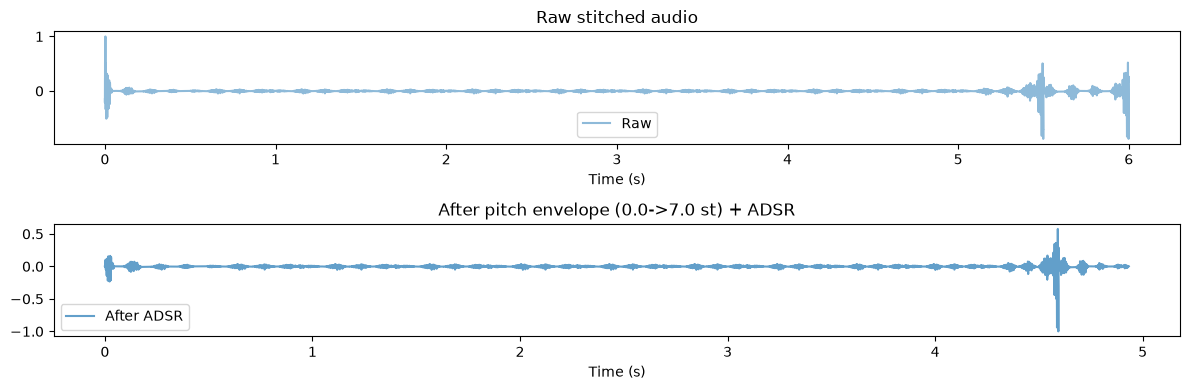

In [6]:
def apply_adsr(audio, attack, decay, sustain, release, sr=24000):
    """Apply ADSR amplitude envelope to audio."""
    total = len(audio)
    a_samples = int(attack * sr)
    d_samples = int(decay * sr)
    r_samples = int(release * sr)
    s_start = a_samples + d_samples
    s_end = max(s_start + 1, total - r_samples)
    
    envelope = torch.ones(total)
    
    # Attack: 0 -> 1
    if a_samples > 0:
        envelope[:a_samples] = torch.linspace(0, 1, a_samples)
    
    # Decay: 1 -> sustain
    if d_samples > 0 and s_start < total:
        actual_d = min(d_samples, total - a_samples)
        envelope[a_samples:a_samples + actual_d] = torch.linspace(1, sustain, actual_d)
    
    # Sustain: hold
    if s_end > s_start and s_end <= total:
        envelope[s_start:s_end] = sustain
    
    # Release: sustain -> 0
    if r_samples > 0 and s_end < total:
        actual_r = min(r_samples, total - s_end)
        envelope[s_end:s_end + actual_r] = torch.linspace(sustain, 0, actual_r)
    
    return audio * envelope

env_audio = apply_adsr(pitched_audio, ADSR_ATTACK, ADSR_DECAY, ADSR_SUSTAIN, ADSR_RELEASE, SAMPLE_RATE)

# Re-normalize
peak = env_audio.abs().max()
if peak > 0:
    env_audio = env_audio / peak

print(f'After ADSR: {env_audio.shape[-1]} samples ({env_audio.shape[-1]/SAMPLE_RATE:.2f}s)')

# Plot the envelope
fig, axes = plt.subplots(2, 1, figsize=(12, 4))
t = torch.arange(len(raw_audio)) / SAMPLE_RATE
axes[0].plot(t.numpy(), raw_audio.numpy(), alpha=0.5, label='Raw')
axes[0].set_title('Raw stitched audio')
axes[0].set_xlabel('Time (s)')
axes[0].legend()

t_env = torch.arange(len(env_audio)) / SAMPLE_RATE
axes[1].plot(t_env.numpy(), env_audio.numpy(), alpha=0.7, label='After ADSR')
axes[1].set_title(f'After pitch envelope ({PITCH_START}->{PITCH_END} st) + ADSR')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 5: Apply timbral filtering

Lowpass and highpass filters shape the spectral content.

In [7]:
def apply_filters(audio, lp_cutoff, hp_cutoff, sr=24000):
    """Apply lowpass and highpass filters via biquad."""
    audio_2d = audio.unsqueeze(0)  # (1, T)
    
    if lp_cutoff > 0 and lp_cutoff < sr / 2:
        audio_2d = torchaudio.functional.lowpass_biquad(audio_2d, sr, lp_cutoff)
    
    if hp_cutoff > 0 and hp_cutoff < sr / 2:
        audio_2d = torchaudio.functional.highpass_biquad(audio_2d, sr, hp_cutoff)
    
    return audio_2d.squeeze()

final_audio = apply_filters(env_audio, LP_CUTOFF, HP_CUTOFF, SAMPLE_RATE)

# Final normalization
peak = final_audio.abs().max()
if peak > 0:
    final_audio = final_audio / peak

print(f'Final audio: {final_audio.shape[-1]} samples ({final_audio.shape[-1]/SAMPLE_RATE:.2f}s)')
print(f'Filters: LP={LP_CUTOFF}Hz HP={HP_CUTOFF}Hz')

Final audio: 118394 samples (4.93s)
Filters: LP=8000Hz HP=80Hz


## Step 6: Playback and comparison

In [8]:
print('Final generated audio (with pitch envelope, ADSR, filtering):')
display(Audio(final_audio.numpy(), rate=SAMPLE_RATE))

Final generated audio (with pitch envelope, ADSR, filtering):


In [9]:
print('Raw stitched audio (no post-processing):')
display(Audio(raw_audio.numpy(), rate=SAMPLE_RATE))

Raw stitched audio (no post-processing):


In [10]:
print('With pitch envelope only (no ADSR/filter):')
display(Audio(pitched_audio.numpy(), rate=SAMPLE_RATE))

With pitch envelope only (no ADSR/filter):


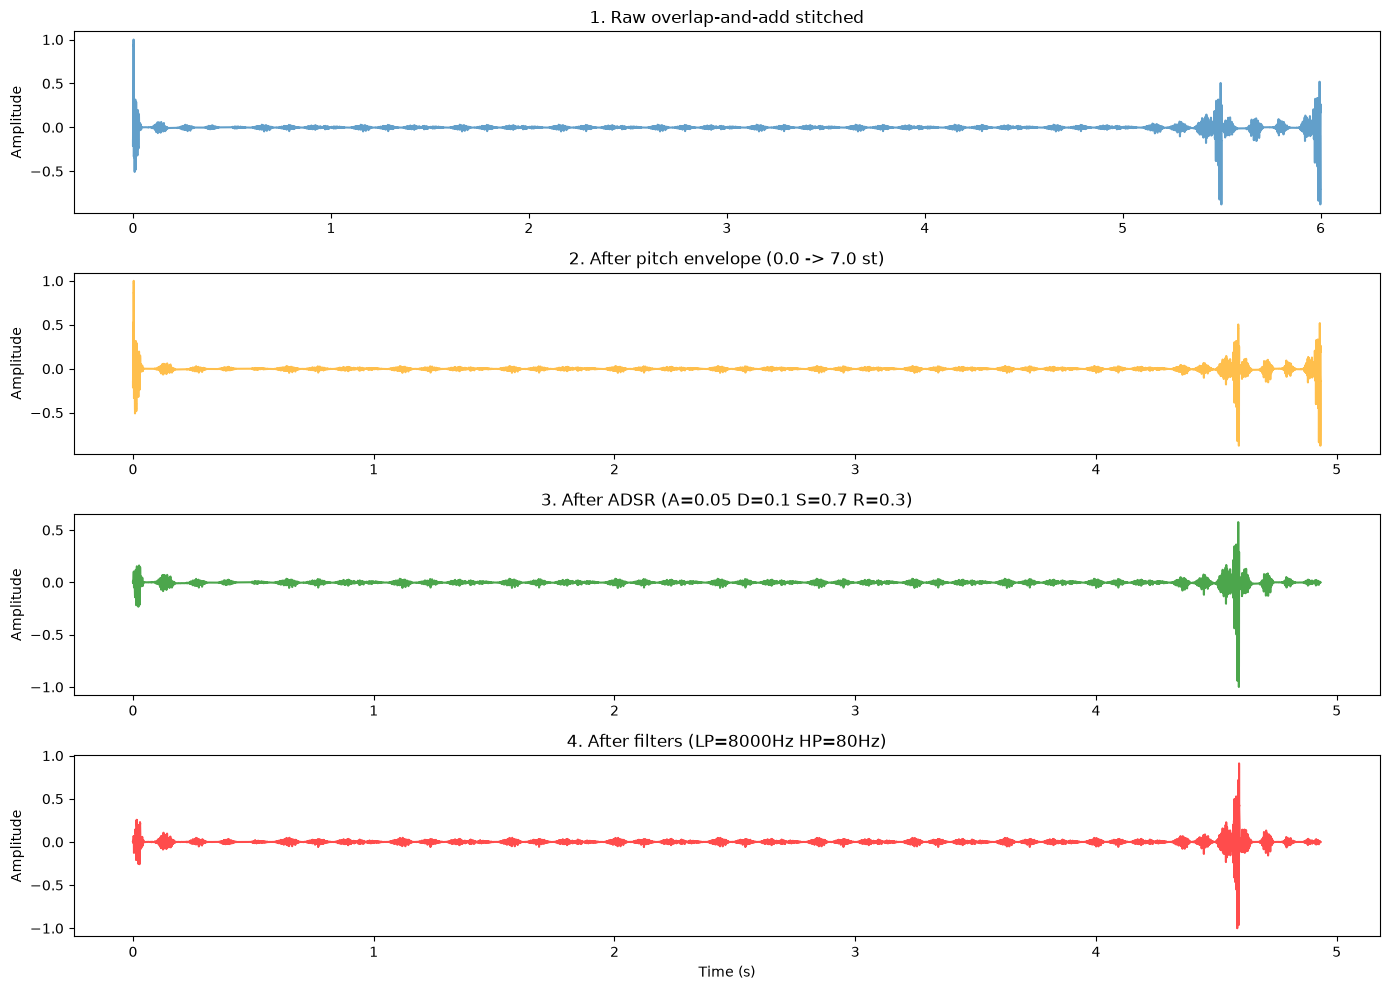

In [11]:
# Plot full pipeline comparison
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)

# Raw waveform
t1 = torch.arange(len(raw_audio)) / SAMPLE_RATE
axes[0].plot(t1.numpy(), raw_audio.numpy(), alpha=0.7)
axes[0].set_title('1. Raw overlap-and-add stitched')
axes[0].set_ylabel('Amplitude')

# After pitch
t2 = torch.arange(len(pitched_audio)) / SAMPLE_RATE
axes[1].plot(t2.numpy(), pitched_audio.numpy(), alpha=0.7, color='orange')
axes[1].set_title(f'2. After pitch envelope ({PITCH_START} -> {PITCH_END} st)')
axes[1].set_ylabel('Amplitude')

# After ADSR
t3 = torch.arange(len(env_audio)) / SAMPLE_RATE
axes[2].plot(t3.numpy(), env_audio.numpy(), alpha=0.7, color='green')
axes[2].set_title(f'3. After ADSR (A={ADSR_ATTACK} D={ADSR_DECAY} S={ADSR_SUSTAIN} R={ADSR_RELEASE})')
axes[2].set_ylabel('Amplitude')

# After filtering
t4 = torch.arange(len(final_audio)) / SAMPLE_RATE
axes[3].plot(t4.numpy(), final_audio.numpy(), alpha=0.7, color='red')
axes[3].set_title(f'4. After filters (LP={LP_CUTOFF}Hz HP={HP_CUTOFF}Hz)')
axes[3].set_ylabel('Amplitude')
axes[3].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## Step 7: Generate variations

Quickly generate different sounds by changing only the seed and pitch knobs.
The trained models are reused.

In [12]:
def generate_with_knobs(seed, pitch_start, pitch_end, attack, release, lp, hp, label=''):
    """Full generation pipeline with custom knobs (reuses trained models)."""
    # Generate segments
    segs = []
    for i in range(num_segments):
        seg = generate_segment(seed + i * 1000, STEPS, TEMPERATURE, USE_C_SPEC)
        segs.append(seg)
    audio = overlap_add(segs, OVERLAP_FRAC, SAMPLE_RATE)
    if len(audio) > TOTAL_LENGTH:
        audio = audio[:TOTAL_LENGTH]
    elif len(audio) < TOTAL_LENGTH:
        audio = torch.nn.functional.pad(audio, (0, TOTAL_LENGTH - len(audio)))
    
    # Pitch envelope
    audio = apply_pitch_envelope(audio, pitch_start, pitch_end, PITCH_CURVE, SAMPLE_RATE)
    
    # ADSR
    audio = apply_adsr(audio, attack, ADSR_DECAY, ADSR_SUSTAIN, release, SAMPLE_RATE)
    
    # Filters
    audio = apply_filters(audio, lp, hp, SAMPLE_RATE)
    
    # Normalize
    peak = audio.abs().max()
    if peak > 0:
        audio = audio / peak
    
    print(f'{label} (seed={seed}, pitch={pitch_start}->{pitch_end}, LP={lp}, HP={hp})')
    display(Audio(audio.numpy(), rate=SAMPLE_RATE))
    return audio

# Variation 1: rising pitch
v1 = generate_with_knobs(seed=100, pitch_start=0, pitch_end=12, attack=0.1, release=0.5,
                         lp=6000, hp=100, label='Rising octave')

Rising octave (seed=100, pitch=0->12, LP=6000, HP=100)


In [13]:
# Variation 2: falling pitch, dark timbre
v2 = generate_with_knobs(seed=200, pitch_start=7, pitch_end=-5, attack=0.3, release=0.8,
                         lp=3000, hp=50, label='Falling fifth, dark')

Falling fifth, dark (seed=200, pitch=7->-5, LP=3000, HP=50)


In [14]:
# Variation 3: no pitch shift, bright, plucky
v3 = generate_with_knobs(seed=300, pitch_start=0, pitch_end=0, attack=0.005, release=0.1,
                         lp=12000, hp=200, label='No shift, bright pluck')

No shift, bright pluck (seed=300, pitch=0->0, LP=12000, HP=200)


In [15]:
# Variation 4: dramatic sweep
v4 = generate_with_knobs(seed=42, pitch_start=-7, pitch_end=19, attack=0.5, release=1.0,
                         lp=8000, hp=80, label='Dramatic sweep (-7 to +19)')

Dramatic sweep (-7 to +19) (seed=42, pitch=-7->19, LP=8000, HP=80)


## Summary

This notebook extends the 1-second generation pipeline to **5-8 seconds**
via overlap-and-add stitching, with **post-processing sound shaping knobs**:

| Knob | What it controls |
|------|-------------------|
| `SEGMENT_SECONDS` | Total output length (5-8s) |
| `OVERLAP_FRAC` | Crossfade overlap (0.25-0.75) |
| `PITCH_START` / `PITCH_END` | Pitch envelope in semitones |
| `PITCH_CURVE` | `'linear'` or `'exponential'` pitch ramp |
| `ADSR_ATTACK/DECAY/SUSTAIN/RELEASE` | Amplitude envelope |
| `LP_CUTOFF` / `HP_CUTOFF` | Timbral filtering (Hz) |
| `SEED` / `STEPS` / `TEMPERATURE` / `USE_C_SPEC` | Generation knobs |

### Approach
- Train on 1s clips (fast CPU training)
- Generate N segments with different seeds
- Overlap-and-add with crossfade for seamless stitching
- Variable-speed resampling for pitch envelope
- ADSR for amplitude shaping
- Lowpass/highpass for timbral control

### Next steps
- Train DiT on longer latents directly (avoids stitching artifacts)
- Add CLAP text conditioning (Phase 2)
- Use real EnCodec + ESC-50 for richer sounds